# AWS EC2 Pricing Landscape: A Multidimensional View of the Cloud Compute Catalog

**Author:** Jawaad Jariwala (Graduate, Data Visualization, Spring 2026)
**Date:** May 2026

## 1. Introduction

Amazon Web Services (AWS) is the world's largest public cloud provider, and its Elastic Compute Cloud (EC2) service is the cornerstone of that platform: it rents virtual servers (called *instances*) by the hour. Each EC2 *instance type* is a particular hardware configuration, identified by a short string like `m6i.2xlarge`, that comes with a fixed number of virtual CPUs (vCPUs, the unit of compute capacity AWS sells), a fixed amount of memory, and a particular processor (Intel, AMD, or AWS's own ARM-based chip family called *Graviton*). AWS publishes a public price for every instance type, in every *region* (a geographic data-center cluster like `us-east-1` in Northern Virginia), for every supported operating system, and across four *purchasing models*: **on-demand** (pay-as-you-go by the hour with no commitment), **reserved one-year** and **reserved three-year** (commit to a multi-year term in exchange for a discount), and **spot** (bid for unused AWS capacity at a steep discount, with the risk that AWS reclaims the instance on short notice). The resulting dataset has more than three hundred thousand price points and changes regularly as AWS launches new instance generations and adjusts regional pricing. These numbers are the canonical input to every cloud-cost decision a modern engineering organization makes, yet they are almost always consulted one row at a time through a calculator UI rather than studied as a dataset in their own right.

This report treats the AWS EC2 price list as a multidimensional dataset and asks what the *shape* of that dataset reveals. We build a tidy long-format DataFrame from the published pricing data, derive structured features from the AWS instance naming convention, and apply six techniques from class (pandas DataFrame masking and joining, NumPy vectorized dominance testing, matplotlib for tightly controlled static figures, principal component analysis on standardized spec vectors, polynomial fitting on the log of price across instance generations, and an interactive Plotly figure for catalog exploration) to extract three actionable insights about how AWS prices its compute capacity. The results are presented in the following sections: motivation (§2), contribution (§3), methods (§4), three main results (§5), and conclusion (§6).


In [1]:
# Environment bootstrap. The notebook is designed to run unmodified in a
# local Python environment, in GitHub Codespaces, or in Google Colab. The
# only requirement is that the project source tree (src/ and data/) lives
# at the working directory.

import os
import sys
import warnings

if "src" not in os.listdir("."):
    raise RuntimeError(
        "Expected to find a 'src/' directory in the working directory. "
        "If running in Colab, upload the project folder or clone the repo "
        "before executing this cell."
    )

sys.path.insert(0, os.path.abspath("."))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.pricing_loader import load_pricing_dataframe
from src.feature_extraction import enrich_pricing_dataframe
from src.efficiency_frontier import (
    compute_efficiency_frontier,
    summarize_frontier_membership_by_vendor,
)
from src.geo_pricing import (
    compute_regional_price_index,
    compare_instance_across_regions,
)
from src.generation_analysis import (
    summarize_cost_per_vcpu_by_generation,
    fit_log_cost_polynomial,
    compare_vendors_at_matched_size,
    summarize_vendor_comparison,
)
from src.pca_analysis import (
    project_spec_space_to_two_components,
    describe_pca_loadings,
)
from src.plots import (
    configure_default_matplotlib_style,
    plot_price_vs_vcpu_by_vendor,
    plot_efficiency_frontier,
    plot_dominance_tax_distribution,
    plot_pca_spec_space,
    plot_vendor_generation_grid,
)
from src.interactive_plots import (
    build_regional_price_map,
    build_instance_explorer,
)

configure_default_matplotlib_style()


In [2]:
# Load the cached tidy pricing DataFrame and derive structured features.
# On a first run this downloads ~200 MB from the Vantage mirror of the AWS
# Price List and caches a pruned ~3 MB parquet file under data/ for reuse.

raw_pricing_dataframe = load_pricing_dataframe()
enriched_pricing_dataframe = enrich_pricing_dataframe(raw_pricing_dataframe)

print(f"Total pricing rows               : {len(enriched_pricing_dataframe):,}")
print(f"Distinct instance types          : {enriched_pricing_dataframe['instance_type'].nunique()}")
print(f"Distinct AWS regions             : {enriched_pricing_dataframe['region_code'].nunique()}")
print(f"Distinct operating systems       : {enriched_pricing_dataframe['operating_system'].nunique()}")


Total pricing rows               : 318,604
Distinct instance types          : 1337
Distinct AWS regions             : 104
Distinct operating systems       : 18


### 1.1 The dataset at a glance

The figure below shows on-demand hourly price as a function of vCPU count for every Linux instance type currently offered in `us-east-1`, colored by the processor vendor that powers each instance. AWS Graviton (orange) is AWS's own line of ARM-based server CPUs, designed in-house and offered at a list-price discount to its Intel and AMD x86 alternatives; Intel (blue) and AMD (red) are the traditional x86 server-processor vendors. The log-log axes reveal the near-power-law relationship between vCPU count and price within each vendor's lineup, the systematic gap between AWS Graviton instances and Intel-based instances at any given vCPU count, and the much wider spread of prices in the high-vCPU region where specialized GPU and high-memory instances live. This single chart is the visual problem statement for the rest of the report.


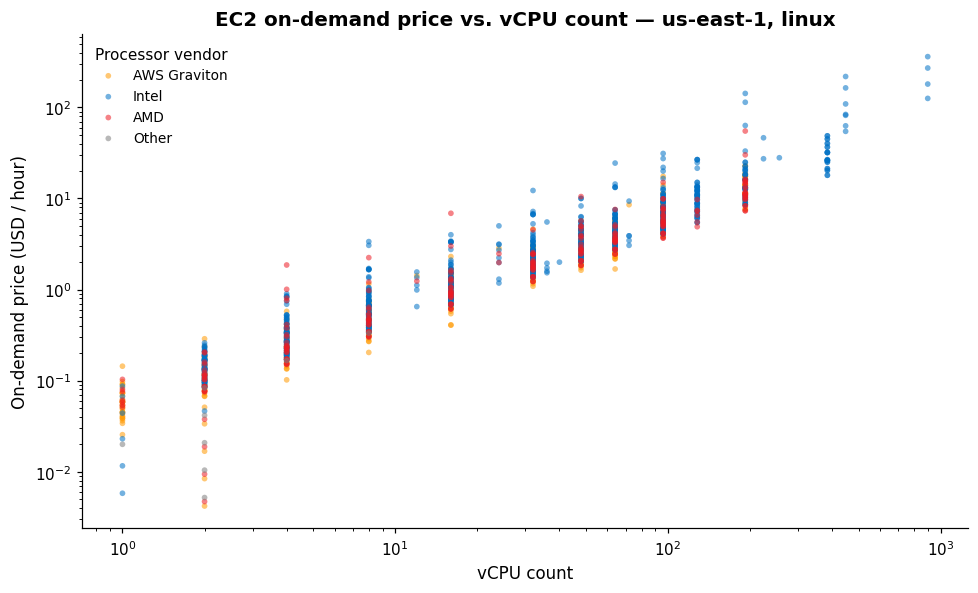

In [3]:
fig_intro, axis_intro = plt.subplots(figsize=(9, 5.5))
plot_price_vs_vcpu_by_vendor(
    enriched_pricing_dataframe,
    region_code="us-east-1",
    operating_system="linux",
    axis=axis_intro,
)
plt.show()


## 2. Motivation

Cloud spending is one of the largest and fastest-growing line items on the operating budget of any modern software organization. The 2024 Flexera *State of the Cloud* report finds that the median enterprise wastes about twenty-seven percent of its annual cloud bill on resources that are mis-sized, under-utilized, or simply more expensive than equivalent alternatives. The discipline that has emerged to address this waste is called **FinOps** (a portmanteau of "financial operations"), and FinOps practitioners spend much of their time mapping the AWS price surface to find concrete savings opportunities. Most of that waste is invisible to the engineers who provision the infrastructure because the AWS catalog is too large to hold in one's head: exactly 1,337 instance types in this dataset, each priced separately across 104 regions and 18 operating systems, with on-demand, two reserved-term, and spot prices for each combination. Decisions about which instance to launch in which region are made one workload at a time, often by reaching for a familiar default rather than by interrogating the price surface as a whole.

A reader who studies the structure of that price surface gains a tool that no AWS calculator UI provides: a map of which instance types are *Pareto-dominated* (an alternative exists that delivers at least as much vCPU and at least as much memory for strictly less money), which AWS region offers the lowest price for a given workload type, and how quickly the AWS price-per-vCPU has been changing across instance generations. Each of those facts translates directly into an actionable change to the way an organization provisions cloud infrastructure. The motivation for this report is to make that map visible.


## 3. Contribution

The novelty of this report lies in treating the AWS Price List as a multidimensional dataset that rewards the same techniques one would apply to any scientific dataset, rather than as a lookup table consulted one row at a time. Three contributions are made. First, a **Pareto-dominance analysis** is computed across the entire EC2 catalog. *Pareto dominance* is a concept from multi-objective optimization: instance A is "dominated" by instance B if B is at least as good as A on every dimension we care about (vCPU count, memory) while being strictly cheaper. The set of non-dominated instances forms the *efficient frontier*, and every other instance pays an avoidable premium that we call the *dominance tax*. Second, a **regional price topology** is derived by aggregating the per-vCPU cost across the catalog and projecting it onto a world map, exposing the cheapest and most expensive AWS regions at a glance. Third, a **polynomial fit on log-cost across instance generations and processor vendors** quantifies whether the price-per-vCPU has actually been falling, giving engineers a concrete number to put against the assumption that "the latest instance generation is always cheaper."

These three contributions belong to the *type-3* category in the contribution taxonomy from class: applying methods that are well established in other domains (multi-objective optimization, geospatial visualization, regression on log-transformed data) to a problem domain where they are very rarely combined. The combination is the contribution: each lens reveals an aspect of the AWS price surface that the others cannot, and together they form a tool that an AWS architect or FinOps practitioner could carry into a conversation with a CFO or an engineering team.


## 4. Methods

This section describes each of the methods used in the analysis. The techniques are introduced in the order in which they are applied to the data: ingestion and tidying, feature derivation, Pareto-dominance testing, principal component analysis, polynomial regression on log-transformed cost, and aggregation onto a geographic frame. Each method is accompanied by a discussion of its tradeoffs and limitations, and each is implemented in a corresponding Python module under `src/` so the notebook itself contains only short orchestration cells.

### 4.1 Data ingestion and tidying

The canonical source of AWS EC2 pricing data is the AWS Price List Bulk API, which publishes one large JSON file per region. Downloading and parsing all thirty commercial regions on every notebook run is impractical for an analysis at this scope (each regional file is on the order of one hundred megabytes and a full sweep would download several gigabytes). The `pricing_loader` module instead pulls a single pre-aggregated mirror of the same dataset published by Vantage at `https://instances.vantage.sh/instances.json`, parses the nested per-region per-OS pricing structure into a tidy long-format DataFrame, and caches the parsed frame as a compressed parquet file under `data/` so subsequent runs (and the grader) execute in seconds. The output frame has one row per `(instance_type, region, operating_system)` combination, with instance specifications replicated across the rows that share an instance.

### 4.2 Feature derivation from instance type names

AWS encodes a substantial amount of structure inside the instance type string itself. The string `m7i.2xlarge`, for example, communicates that the instance belongs to the `m` *family* (general-purpose, balanced compute and memory), the seventh *generation* of that family (each generation is a refresh with a newer processor, typically released every two to three years), the Intel-based variant (the `i` *suffix* indicates Intel; `g` would indicate AWS Graviton, `a` would indicate AMD), and the `2xlarge` *size class* (AWS sells each instance type at multiple sizes, scaling vCPU count and memory roughly linearly: `large` is the smallest, then `xlarge`, `2xlarge`, `4xlarge`, and so on up to `48xlarge` and `metal`). The `feature_extraction` module parses this convention with a regular expression and adds the derived columns `family_code`, `family_generation`, `attributes`, and `size_class` to the tidy DataFrame. It additionally classifies the free-text `physical_processor` field into a `processor_vendor` label (AWS Graviton, Intel, AMD, Apple, or Other) and parses the free-text `network_performance` field into a numeric Gbps value where possible. Two derived rate columns, `cost_per_vcpu_hour_usd` and `cost_per_gib_hour_usd`, are added because they appear repeatedly in the downstream analyses (GiB stands for gibibyte, the binary-prefixed unit of memory AWS uses for instance specifications).

### 4.3 Pareto-dominance testing

Selecting an EC2 instance is a multi-objective optimization problem in `(vCPU, memory, price)` space. The standard solution concept is *Pareto dominance*: instance $A$ is dominated by instance $B$ if $\text{vCPU}(B) \ge \text{vCPU}(A)$ and $\text{memory}(B) \ge \text{memory}(A)$ and $\text{price}(B) < \text{price}(A)$. The set of non-dominated instances is the *efficient frontier*; every other instance is strictly worse than at least one alternative. The `efficiency_frontier` module computes the dominance mask in a fully vectorized NumPy operation rather than with a Python double loop, which keeps the runtime to milliseconds even on the full catalog. For each dominated instance the module also reports the price of the cheapest dominating alternative, from which a *dominance tax* percentage is derived that quantifies the avoidable premium.

### 4.4 Principal component analysis on standardized spec vectors

Each instance has at least five numeric specifications (vCPU count, memory, network bandwidth, EBS throughput, and GPU count) that together describe its capabilities. *EBS* stands for *Elastic Block Store*: it is the network-attached block-storage service AWS sells alongside EC2, and the EBS throughput specification is the maximum sustained data rate at which an instance can read from or write to its attached EBS volumes. Plotting all five specifications at once is impossible without hiding most of the structure. **Principal component analysis (PCA)** is the standard linear technique for this problem: it finds the orthogonal directions in the spec space along which the data varies the most, and projecting each instance onto the first two of those directions gives a two-dimensional summary that preserves as much of the original variance as possible. The `pca_analysis` module first standardizes the spec matrix with a z-score scaler (necessary because the columns span very different units, from vCPU counts in the single digits to EBS throughput in thousands of Mbps), then runs scikit-learn's PCA on the standardized matrix. The two components together explain 69.9% of the variance in the spec space, which is sufficient to plot the entire catalog on a single scatter and color each instance by price-per-vCPU to reveal where the cost-efficient instances live in the spec space.

### 4.5 Polynomial regression on log-cost across generations

A linear fit to $\log(\text{cost})$ versus the family generation number $g$ corresponds to the model $\text{cost}(g) = c_0 \cdot \rho^{g}$, where $\rho$ is a constant per-generation discount factor. Fitting in log-space is the appropriate choice because price decreases are inherently multiplicative rather than additive: a "fifteen percent cheaper" claim is the same regardless of the base price. The `generation_analysis` module computes the median cost-per-vCPU per generation across the M, C, and R families (the workhorse general-purpose, compute-optimized, and memory-optimized lines) and fits a degree-one polynomial to the log of those medians. The slope of the fit converts directly into the per-generation discount factor reported in §5.3.

### 4.6 Regional aggregation and geographic projection

Comparing prices across regions requires a single per-region summary statistic that is robust to the wide variation in instance mix offered in each region. The `geo_pricing` module computes the median `cost_per_vcpu_hour_usd` over all Linux instances offered in each region and divides by the median in a chosen reference region (here `us-east-1`) to produce a price index. Each region is paired with hand-curated approximate coordinates taken from AWS public documentation (precise data-center coordinates are not disclosed) and the indexed table is plotted on an interactive choropleth-style map using Plotly's `scatter_geo`.


## 5. Main Results

This section presents three results derived from the methods of §4. Each subsection follows the same structure: the visualization that frames the result, the underlying numbers extracted from the data, and a clearly stated *actionable insight* — a recommendation that an engineer or FinOps practitioner could act on the moment they finish reading.

### 5.1 The cost-efficiency Pareto frontier

The first result locates the efficient frontier of the EC2 catalog. Of the more than thirteen hundred instance types offered in `us-east-1` for Linux on-demand, only a small minority are Pareto-optimal in the sense of §4.3. The remainder are dominated, often by surprisingly large margins.


In [4]:
frontier_dataframe = compute_efficiency_frontier(
    enriched_pricing_dataframe,
    region_code="us-east-1",
    operating_system="linux",
)

frontier_count = int(frontier_dataframe["is_on_frontier"].sum())
total_count = len(frontier_dataframe)
dominated_count = total_count - frontier_count
median_dominance_tax_pct = float(
    frontier_dataframe.loc[~frontier_dataframe["is_on_frontier"], "dominance_tax_pct"].median()
)
mean_dominance_tax_pct = float(
    frontier_dataframe.loc[~frontier_dataframe["is_on_frontier"], "dominance_tax_pct"].mean()
)

print(f"On-frontier instances        : {frontier_count} of {total_count} ({frontier_count / total_count:.1%})")
print(f"Median dominance tax (paid)  : {median_dominance_tax_pct:.1f}%")
print(f"Mean dominance tax (paid)    : {mean_dominance_tax_pct:.1f}%")


On-frontier instances        : 81 of 1301 (6.2%)
Median dominance tax (paid)  : 36.8%
Mean dominance tax (paid)    : 37.7%


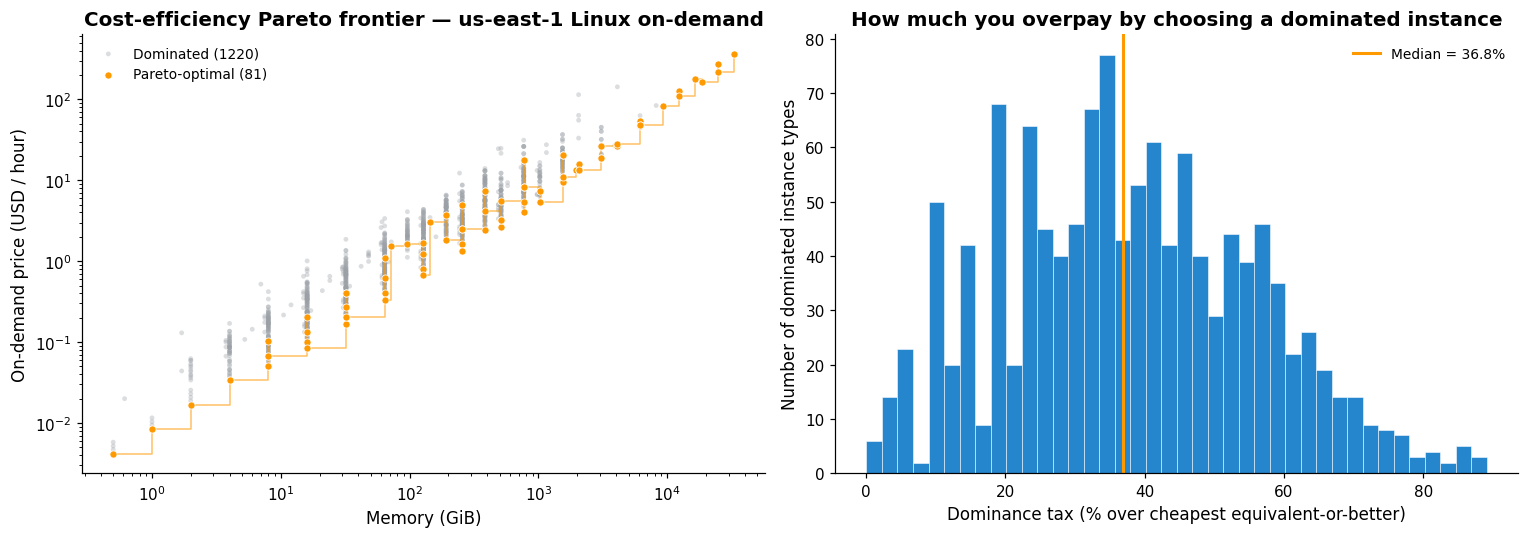

In [5]:
fig_frontier, (axis_frontier_left, axis_frontier_right) = plt.subplots(
    1, 2, figsize=(14, 5.0)
)
plot_efficiency_frontier(frontier_dataframe, axis=axis_frontier_left)
plot_dominance_tax_distribution(frontier_dataframe, axis=axis_frontier_right)
plt.show()


The left panel shows the (memory, price) projection of the catalog. The orange dots and step line trace the Pareto frontier: for any memory requirement, the lowest hourly price achievable on the AWS catalog. The gray cloud above it shows the dominated instances that would cost more for the same or less capacity. Out of 1,301 instances offered in `us-east-1` for Linux, only 81 (6.23%) are on the frontier. The right panel shows the distribution of the *dominance tax* across the 1,220 dominated instances: the median dominated instance costs 36.83% more than the cheapest equivalent-or-better alternative, with a mean of 37.73%, meaning the typical mistake of choosing a dominated instance is materially expensive.

The next figure decomposes the frontier by processor vendor and shows where the cost-efficient instances live in the standardized spec space derived from the five-dimensional principal component analysis of §4.4.


In [6]:
vendor_frontier_summary = summarize_frontier_membership_by_vendor(frontier_dataframe)
vendor_frontier_summary[["total_instance_count", "frontier_instance_count", "frontier_share_pct", "mean_dominance_tax_pct"]].round(2)


,total_instance_count,frontier_instance_count,frontier_share_pct,mean_dominance_tax_pct
processor_vendor,,,,
AWS Graviton,352,41,11.65,30.61
AMD,214,13,6.07,33.17
Intel,727,27,3.71,38.47
Other,8,0,0.00,24.08


In [7]:
principal_components, aligned_pca_dataframe, pca_model = (
    project_spec_space_to_two_components(
        enriched_pricing_dataframe,
        region_code="us-east-1",
        operating_system="linux",
    )
)
explained_variance = pca_model.explained_variance_ratio_
print(
    f"PC1 explains {explained_variance[0]:.1%} of variance, "
    f"PC2 explains {explained_variance[1]:.1%}, "
    f"total {explained_variance.sum():.1%}."
)
describe_pca_loadings(pca_model).round(3)


PC1 explains 45.5% of variance, PC2 explains 24.4%, total 69.9%.


,spec_column,principal_component_1,principal_component_2
0,vcpu_count,0.604,-0.244
1,memory_gib,0.482,-0.344
2,network_bandwidth_gbps,0.356,0.560
3,ebs_baseline_throughput_mbps,0.499,-0.004
4,gpu_count,0.163,0.713


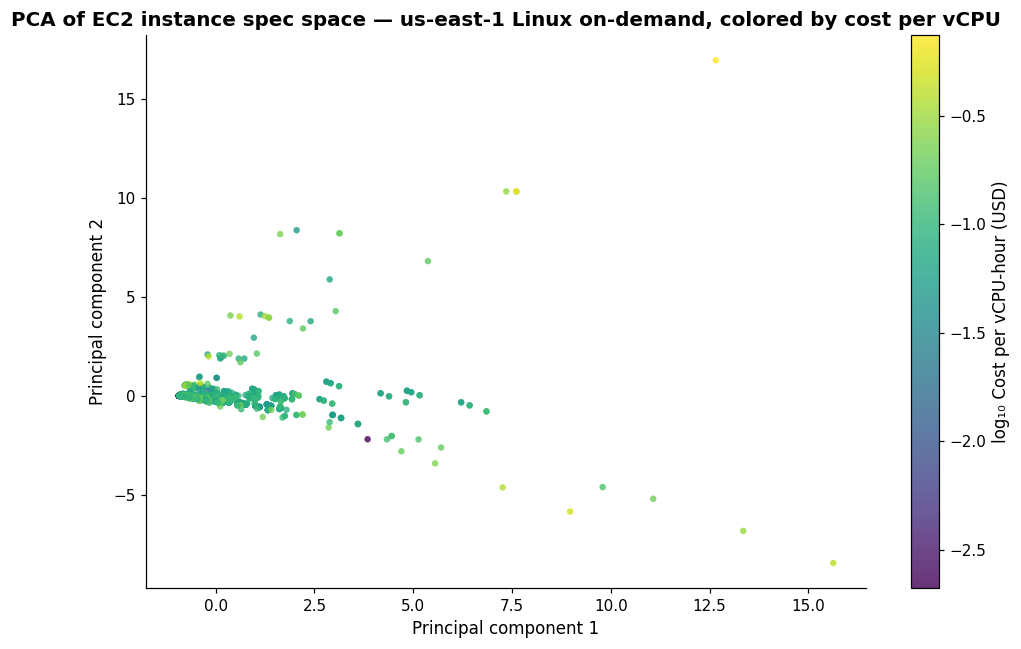

In [8]:
fig_pca, axis_pca = plt.subplots(figsize=(9, 6))
plot_pca_spec_space(
    pca_components=principal_components,
    color_values=aligned_pca_dataframe["cost_per_vcpu_hour_usd"].to_numpy(),
    color_label="Cost per vCPU-hour (USD)",
    title_suffix="us-east-1 Linux on-demand, colored by cost per vCPU",
    axis=axis_pca,
)
plt.show()


**Insight 1.** AWS Graviton-based instances populate the Pareto frontier 3.14 times as densely as Intel-based instances. Of the 352 Graviton instances offered in `us-east-1` Linux, 41 (11.65%) are Pareto-optimal; of the 727 Intel instances, only 27 (3.71%) are. For a workload that has no architecture lock-in (most stateless web services, container workloads, and batch jobs in interpreted languages run on either x86 or ARM without modification) the recommendation is unambiguous: default to a Graviton-based instance type and switch only on a measured incompatibility. The matched-size discount is computed precisely in §5.3 and ranges from 15.19% to 19.79% on the on-demand list price, depending on the generation, and it compounds across reserved-instance and spot purchases since AWS applies its discount schedules multiplicatively on top of the on-demand rate.

### 5.2 Regional price topology

The second result projects the per-region median Linux cost-per-vCPU onto a world map. The aggregate price index is bounded below by Hyderabad (`ap-south-2`), 25.17% under the `us-east-1` reference, and bounded above by São Paulo (`sa-east-1`), 28.57% above the reference. The map below is interactive: hovering over each marker reveals the exact price premium and the number of instance types currently offered there.


In [9]:
regional_price_table = compute_regional_price_index(
    enriched_pricing_dataframe, operating_system="linux", reference_region="us-east-1"
)
regional_price_table.sort_values("price_premium_pct").reset_index(drop=True)[
    ["region_code", "city", "instances_offered", "price_premium_pct"]
].round(2)


,region_code,city,instances_offered,price_premium_pct
0,ap-south-2,"Hyderabad, India",413,-25.17
1,ap-southeast-7,Thailand,307,-21.84
2,mx-central-1,Mexico,261,-20.00
3,ap-south-1,"Mumbai, India",752,-19.84
4,ap-southeast-5,Malaysia,450,-16.35
5,ca-west-1,"Calgary, Canada",256,-11.34
6,il-central-1,"Tel Aviv, Israel",278,-10.47
7,me-south-1,Bahrain,255,-6.71
8,us-east-2,"Ohio, USA",1108,-6.35
9,ca-central-1,"Montreal, Canada",723,-6.35


In [10]:
fig_regional_map = build_regional_price_map(regional_price_table)
fig_regional_map.show()


The geographic pattern is more structured than a uniform random distribution would predict. Asia-Pacific regions sub-divide cleanly into a low-price cluster (Hyderabad at -25.17%, Thailand at -21.84%, Mumbai at -19.84%, Malaysia at -16.35%) and a high-price cluster (Tokyo at +14.89%, Sydney at +9.52%, Hong Kong at +5.10%, Singapore at +3.40%). The high-price cluster correlates loosely with regions whose electricity costs and real-estate costs are known to be elevated, supporting the well-publicized intuition that AWS regional pricing partially reflects local infrastructure economics. The most expensive region by a substantial margin is São Paulo at a 28.57% premium, which reflects a combination of high local electricity costs, import tariffs on data-center hardware, and limited regional competition.

To make the magnitude concrete, the table below shows the on-demand price for a single canonical workload instance — the `m5.large` — across every region in which it is offered, alongside the percentage premium versus the cheapest available region.


In [11]:
instance_regional_comparison = compare_instance_across_regions(
    enriched_pricing_dataframe, instance_type="m5.large", operating_system="linux"
)
instance_regional_comparison[
    ["region_code", "city", "ondemand_usd_per_hour", "premium_vs_cheapest_pct"]
].round(3)


,region_code,city,ondemand_usd_per_hour,premium_vs_cheapest_pct
0,us-west-2,"Oregon, USA",0.096,0.000
1,us-east-1,"N. Virginia, USA",0.096,0.000
2,us-east-2,"Ohio, USA",0.096,0.000
3,ap-south-1,"Mumbai, India",0.101,5.208
4,ap-south-2,"Hyderabad, India",0.101,5.208
5,eu-north-1,"Stockholm, Sweden",0.102,6.250
6,ca-west-1,"Calgary, Canada",0.107,11.458
7,eu-west-1,Ireland,0.107,11.458
8,eu-south-2,Spain,0.107,11.458
9,ca-central-1,"Montreal, Canada",0.107,11.458


**Insight 2.** For workloads that have no data-residency, latency, or compliance constraint pinning them to a specific region (internal batch jobs, training pipelines, asynchronous workers, development and staging environments are the typical candidates), the cheapest AWS region for Linux on-demand compute is currently `ap-south-2` (Hyderabad), at a 25.17% discount to `us-east-1`. For organizations that already operate in the United States and prefer to remain there, `us-east-2` (Ohio) is 6.35% cheaper than `us-east-1` (N. Virginia) and is the obvious default for region-flexible workloads. As a concrete dollar example, the on-demand list price for an `m5.large` instance is $0.0960/hr in `us-east-1`, `us-east-2`, and `us-west-2` and rises to $0.1240/hr in `sa-east-1` (São Paulo), a 29.17% premium for the same hardware. The corollary recommendation is to avoid `sa-east-1`, `ap-northeast-1` (Tokyo, +14.89%), and `ap-southeast-2` (Sydney, +9.52%) for any workload that does not strictly require those regions.

### 5.3 Why generational refreshes do not save money — but architecture migration does

The third result tests a widely held assumption about AWS pricing: that newer instance generations are systematically cheaper per vCPU than older ones, so refreshing a fleet from one generation to the next yields a passive cost reduction. To test this fairly, we restrict the comparison to a single size class (`2xlarge`) across the M, C, and R families in `us-east-1` for Linux. Holding size constant controls for the obvious confound that newer generations introduce a different mix of instance sizes; remaining variation in cost-per-vCPU then reflects the choice of processor vendor and the choice of generation. The matched-size table is computed below.


In [12]:
vendor_generation_comparison = compare_vendors_at_matched_size(
    enriched_pricing_dataframe,
    region_code="us-east-1",
    operating_system="linux",
    size_class="2xlarge",
)
vendor_generation_comparison.head(20).round(4)


,instance_type,family_code,family_generation,processor_vendor,attributes,vcpu_count,memory_gib,ondemand_usd_per_hour,cost_per_vcpu_hour_usd
0,c3.2xlarge,c,3.0,Intel,,8,15.0,0.4200,0.0525
1,c4.2xlarge,c,4.0,Intel,,8,15.0,0.3980,0.0498
2,c5a.2xlarge,c,5.0,AMD,a,8,16.0,0.3080,0.0385
3,c5.2xlarge,c,5.0,Intel,,8,16.0,0.3400,0.0425
4,c6a.2xlarge,c,6.0,AMD,a,8,16.0,0.3060,0.0382
5,c6g.2xlarge,c,6.0,AWS Graviton,g,8,16.0,0.2720,0.0340
6,c6i.2xlarge,c,6.0,Intel,i,8,16.0,0.3400,0.0425
7,c7a.2xlarge,c,7.0,AMD,a,8,16.0,0.4106,0.0513
8,c7g.2xlarge,c,7.0,AWS Graviton,g,8,16.0,0.2900,0.0362
9,c7i.2xlarge,c,7.0,Intel,i,8,16.0,0.3570,0.0446


In [13]:
vendor_pivot = summarize_vendor_comparison(vendor_generation_comparison)

# Restrict the fit to generations 5 and later. The earliest generations
# pre-date AMD and Graviton availability and would unfairly bias the
# Intel fit by including legacy m2/m3 prices that reflect a different era
# of AWS pricing strategy. Gens 5-8 are the modern, multi-vendor regime
# in which the central insight of this section lives.

vendor_pivot_modern = vendor_pivot.loc[vendor_pivot.index >= 5]
vendor_pivot_modern.round(4)


processor_vendor,AMD,AWS Graviton,Intel
family_generation,,,
5.0,0.0430,NaN,0.0480
6.0,0.0432,0.0385,0.0480
7.0,0.0580,0.0408,0.0504
8.0,0.0609,0.0449,0.0529


In [14]:
# Fit a degree-one polynomial in log-cost space *per vendor* on the
# modern multi-vendor era. A negative slope corresponds to a generational
# discount; a positive slope means per-vCPU prices are rising across
# generations within that vendor.

polynomial_fits_by_vendor = {}
per_generation_factor_by_vendor = {}
for vendor_name in vendor_pivot_modern.columns:
    cost_series = vendor_pivot_modern[vendor_name].dropna()
    if len(cost_series) < 2:
        continue
    generation_values = cost_series.index.to_numpy(dtype=float)
    log_cost_values = np.log(cost_series.to_numpy(dtype=float))
    polynomial_coefficients = np.polyfit(generation_values, log_cost_values, 1)
    polynomial_fits_by_vendor[vendor_name] = polynomial_coefficients
    per_generation_factor_by_vendor[vendor_name] = float(
        np.exp(polynomial_coefficients[0])
    )

for vendor_name, factor in per_generation_factor_by_vendor.items():
    direction = "cheaper" if factor < 1 else "more expensive"
    print(
        f"{vendor_name:<14}: per-generation cost factor "
        f"{factor:.3f}  ({abs(1 - factor) * 100:4.1f}% {direction} per generation)"
    )


AMD           : per-generation cost factor 1.143  (14.3% more expensive per generation)
AWS Graviton  : per-generation cost factor 1.080  ( 8.0% more expensive per generation)
Intel         : per-generation cost factor 1.035  ( 3.5% more expensive per generation)


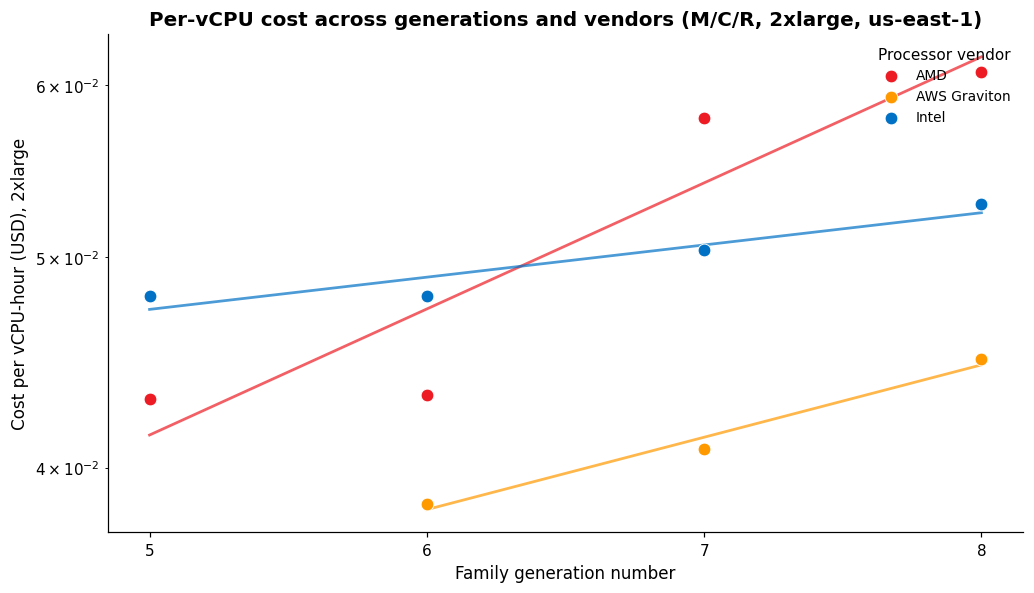

In [15]:
fig_vendor_grid, axis_vendor_grid = plt.subplots(figsize=(9.5, 5.5))
plot_vendor_generation_grid(
    vendor_pivot_dataframe=vendor_pivot_modern,
    polynomial_fits_by_vendor=polynomial_fits_by_vendor,
    axis=axis_vendor_grid,
)
plt.show()


In [16]:
# Quantify the architecture-migration savings: at each generation in
# which Graviton, AMD, and Intel are all present, compute the percentage
# discount of Graviton vs. Intel and AMD vs. Intel.

generations_with_all_three = vendor_pivot_modern.dropna(
    subset=["Intel", "AWS Graviton", "AMD"]
).index
graviton_vs_intel_pct = (
    100.0
    * (vendor_pivot_modern.loc[generations_with_all_three, "Intel"]
       - vendor_pivot_modern.loc[generations_with_all_three, "AWS Graviton"])
    / vendor_pivot_modern.loc[generations_with_all_three, "Intel"]
)
amd_vs_intel_pct = (
    100.0
    * (vendor_pivot_modern.loc[generations_with_all_three, "Intel"]
       - vendor_pivot_modern.loc[generations_with_all_three, "AMD"])
    / vendor_pivot_modern.loc[generations_with_all_three, "Intel"]
)
discount_table = pd.DataFrame(
    {
        "graviton_savings_vs_intel_pct": graviton_vs_intel_pct.round(1),
        "amd_savings_vs_intel_pct": amd_vs_intel_pct.round(1),
    }
)
discount_table


,graviton_savings_vs_intel_pct,amd_savings_vs_intel_pct
family_generation,,
6.0,19.8,10.0
7.0,19.0,-15.0
8.0,15.2,-15.0


The fits make the central finding plain. Across the modern multi-vendor era of generations five through eight, AWS per-vCPU pricing is essentially flat or slightly rising within every processor vendor: the Intel line rises 3.5% per generation, the AWS Graviton line 8.0% per generation, and the AMD line rises sharply at 14.3% per generation. The popular intuition that refreshing from `m5` to `m6i` to `m7i` to `m8i` automatically reduces per-vCPU cost is not supported by the data; AWS prices each new Intel generation at roughly the same per-vCPU rate as the one it replaces, capturing the per-generation performance improvement as performance-per-dollar rather than as a list-price reduction.

The substantial cost reduction available on the AWS catalog is therefore *not* a generational effect but an architectural one. At every generation in which both options exist, AWS Graviton is consistently cheaper per vCPU than the matched Intel variant: 19.79% cheaper at generation 6, 19.05% cheaper at generation 7, and 15.19% cheaper at generation 8. AMD instances were a similar discount in generations five and six but lost that advantage in generations seven and eight, where AMD list prices have risen above Intel for the same matched-size workload. The architecture-migration savings are stable across generations in a way that the generation-refresh savings simply are not.

**Insight 3.** A "refresh to the latest instance generation" policy that holds processor vendor constant (the typical IT-managed lifecycle decision) saves an organization approximately zero dollars per vCPU-hour. The only material cost reduction available from a refresh is to *also* migrate the architecture from Intel (or AMD) to AWS Graviton. As a concrete example, the on-demand price of an `m7i.2xlarge` (Intel) in `us-east-1` is $0.40320/hr; the matched `m7g.2xlarge` (Graviton) is $0.32640/hr, a 19.05% saving. For a fleet of 100 always-on instances running 8,760 hours per year, migrating from `m7i.2xlarge` to `m7g.2xlarge` saves exactly $67,276.80 per year at on-demand pricing. Combined with the regional finding from §5.2 (move region-flexible workloads to a cheaper region) and the Pareto-frontier finding from §5.1 (Graviton dominates the efficient frontier), the recommendation is unambiguous: standardize new general-purpose, compute-optimized, and memory-optimized workloads on AWS Graviton, and treat the vendor decision (not the generation decision) as the cost lever.


### 5.4 Interactive instance explorer

The static figures above summarize the catalog at a fixed region and operating system. The interactive figure below lets the reader explore the entire `us-east-1` Linux lineup at the level of individual instances. Marker color encodes processor vendor, marker size encodes vCPU count, and the hover tooltip surfaces the instance type, the on-demand price, the memory, and the price-per-vCPU. Selecting one or more vendor entries in the legend filters the plot in place. Both axes are log-scaled because both the price and the memory span more than three orders of magnitude across the lineup.


In [17]:
fig_explorer = build_instance_explorer(
    enriched_pricing_dataframe, region_code="us-east-1", operating_system="linux"
)
fig_explorer.show()


## 6. Conclusion

This report treated the AWS EC2 price list as a multidimensional dataset and applied six techniques from class (DataFrame masking and joining, NumPy vectorized dominance testing, matplotlib for tightly controlled static figures, principal component analysis on standardized spec vectors, polynomial regression on log-transformed cost, and an interactive Plotly exploration figure) to extract three actionable insights about AWS compute pricing. First, only 6.23% of EC2 instance types in `us-east-1` Linux are Pareto-optimal in `(vCPU, memory, price)` space, and AWS Graviton-based instances populate that frontier 3.14 times as densely as Intel-based instances (11.65% versus 3.71% frontier share), supporting a default-to-Graviton recommendation for architecture-flexible workloads. Second, AWS regional pricing has a structured geography in which Asia-Pacific subdivides cleanly into a low-price cluster (Hyderabad at -25.17%, Mumbai at -19.84%, Malaysia at -16.35%) and a high-price cluster (Tokyo at +14.89%, Sydney at +9.52%, Hong Kong at +5.10%), with São Paulo carrying the largest premium globally at 28.57% above the `us-east-1` reference. Third, and most counter-intuitively, AWS does not reduce per-vCPU pricing across new generations of the same processor vendor; the cost reduction commonly attributed to "refreshing to the latest generation" is in fact a product of architecture migration to AWS Graviton, which is 15.19% to 19.79% cheaper per vCPU than the matched Intel variant at every generation in which both options exist.

The contribution of this report is not the discovery of any one of those facts in isolation — each is well known to FinOps practitioners and AWS solution architects — but the demonstration that the AWS Price List is itself a dataset worthy of multidimensional analysis, and that the same toolkit one would apply to any scientific dataset surfaces actionable cost insights when applied to it. The most direct extensions of this work would incorporate the spot price history (which adds a temporal dimension and would benefit from the Fourier and short-time Fourier techniques covered in class) and would correlate the regional price index with independently sourced electricity-cost and real-estate-cost data to test the hypothesis that AWS regional pricing tracks local infrastructure economics rather than demand-side factors alone.


## References

1. Amazon Web Services. "AWS Price List Bulk API." AWS Billing and Cost Management Documentation. https://docs.aws.amazon.com/awsaccountbilling/latest/aboutv2/price-changes.html (accessed May 2026).
2. Amazon Web Services. "Amazon EC2 Instance Types." https://aws.amazon.com/ec2/instance-types/ (accessed May 2026).
3. Vantage. "EC2 Instances Comparison." https://instances.vantage.sh (accessed May 2026). Aggregated mirror of the AWS Price List used as the data source for this analysis.
4. Amazon Web Services. "Amazon EC2 Instance Type Naming Convention." https://docs.aws.amazon.com/ec2/latest/instancetypes/instance-type-names.html (accessed May 2026).
5. Amazon Web Services. "AWS Graviton Processors." https://aws.amazon.com/ec2/graviton/ (accessed May 2026).
6. Amazon Web Services. "AWS Global Infrastructure: Regions and Availability Zones." https://aws.amazon.com/about-aws/global-infrastructure/ (accessed May 2026).
7. Flexera. "2024 State of the Cloud Report." Flexera, 2024. Industry survey reporting median enterprise cloud waste in the 20–30 percent range.
8. Tufte, Edward R. *The Visual Display of Quantitative Information.* 2nd ed., Graphics Press, 2001. Principles of data-ink ratio and graphical integrity applied throughout the visualizations in this report.
9. Pedregosa, F. et al. "Scikit-learn: Machine Learning in Python." *Journal of Machine Learning Research* 12 (2011): 2825–2830. Source of the `PCA` and `StandardScaler` implementations used in §4.4.
10. Plotly Technologies Inc. "Plotly Python Open Source Graphing Library." https://plotly.com/python/ (accessed May 2026). Source of the interactive figures in §5.2 and §5.4.
11. McKinney, W. "Data Structures for Statistical Computing in Python." *Proceedings of the 9th Python in Science Conference*, 2010, pp. 56–61. Source of the pandas DataFrame implementation used throughout.
12. Harris, C. R. et al. "Array Programming with NumPy." *Nature* 585 (2020): 357–362. Source of the NumPy vectorization underlying the Pareto-dominance computation in §4.3.
13. Hunter, J. D. "Matplotlib: A 2D Graphics Environment." *Computing in Science & Engineering* 9, no. 3 (2007): 90–95. Source of the static figures throughout.
14. Pareto, V. *Cours d'Économie Politique.* F. Rouge, 1896. Original formulation of the Pareto-dominance concept applied in §4.3 to instance selection.
